<a href="https://colab.research.google.com/github/sswaathiii/Data-Analysis/blob/main/E_COMMERCE_FURNITURE_DATASET_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**E-Commerce Furniture Dataset 2024**

***Logo for Furniture***

Saving Furniture.jpeg to Furniture.jpeg


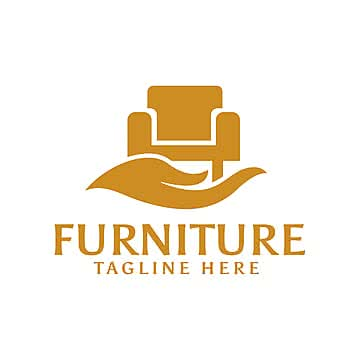

In [ ]:
from google.colab import files
from IPython.display import Image

# This will open a 'Choose File' button
uploaded = files.upload()

# Replace 'your_image.png' with your actual filename
Image('/content/Furniture.jpeg', width=300)


**Data Collection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('/content/ecommerce_furniture_2024 (1).csv')


In [ ]:
data.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,State,Category,Product_Name,Material,Quantity,Unit_Price,Discount,Total_Sales,Payment_Mode,Delivery_Status,Rating
0,ORD1000,2024-04-15,CUST379,Customer_30,Hyderabad,Karnataka,Sofa,3-Seater Sofa,Plastic,2,37936,0.10,68284.80,UPI,Cancelled,1
1,ORD1001,2024-06-25,CUST695,Customer_179,Delhi,Tamil Nadu,Sofa,Recliner Sofa,Metal,3,27571,0.05,78577.35,Card,Cancelled,5
2,ORD1002,2024-09-02,CUST453,Customer_157,Delhi,Delhi,Bed,Single Bed,Plastic,1,20342,0.15,17290.70,Card,Cancelled,3
3,ORD1003,2024-02-17,CUST693,Customer_183,Chennai,Delhi,Table,Dining Table,Plastic,1,13360,0.10,12024.00,Cash on Delivery,Pending,2
4,ORD1004,2024-01-09,CUST672,Customer_128,Hyderabad,Karnataka,Sofa,Recliner Sofa,Plastic,4,5419,0.15,18424.60,Cash on Delivery,Delivered,1


In [ ]:
data.shape


(250, 16)

In [ ]:
data.index


RangeIndex(start=0, stop=250, step=1)

In [ ]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'City',
       'State', 'Category', 'Product_Name', 'Material', 'Quantity',
       'Unit_Price', 'Discount', 'Total_Sales', 'Payment_Mode',
       'Delivery_Status', 'Rating'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         250 non-null    object 
 1   Order_Date       250 non-null    object 
 2   Customer_ID      250 non-null    object 
 3   Customer_Name    250 non-null    object 
 4   City             250 non-null    object 
 5   State            250 non-null    object 
 6   Category         250 non-null    object 
 7   Product_Name     250 non-null    object 
 8   Material         250 non-null    object 
 9   Quantity         250 non-null    int64  
 10  Unit_Price       250 non-null    int64  
 11  Discount         250 non-null    float64
 12  Total_Sales      250 non-null    float64
 13  Payment_Mode     250 non-null    object 
 14  Delivery_Status  250 non-null    object 
 15  Rating           250 non-null    int64  
dtypes: float64(2), int64(3), object(11)
memory usage: 31.4+ KB


 **Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/ecommerce_furniture_2024 (1).csv')

# Handle missing values - common in price and tagText
df['Quantity'] = df['Quantity'].fillna('No Tag')
df.dropna(subset=['Unit_Price', 'Discount'], inplace=True)

# Convert price columns to numeric (handling currency symbols if present)
df['Unit_Price'] = pd.to_numeric(df['Unit_Price'].astype(str).str.replace('₹', '').str.replace(',', ''), errors='coerce')
df['Total_Sales'] = pd.to_numeric(df['Total_Sales'].astype(str).str.replace('₹', '').str.replace(',', ''), errors='coerce')


**Text Processing (NLP**)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare Features and Target
# Features: price, originalPrice, discount_percent, category_encoded, etc.
X = df[['Unit_Price', 'Quantity', 'Discount', 'Rating']]
y = df['Total_Sales']

# 2. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
predictions = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions)}")
print(f"R-squared Score: {r2_score(y_test, predictions)}")


Mean Absolute Error: 2677.9336551590886
R-squared Score: 0.9911189750342749


**Visualise the distributions of ratings and compensations**

**Histogram of Unit_Price**

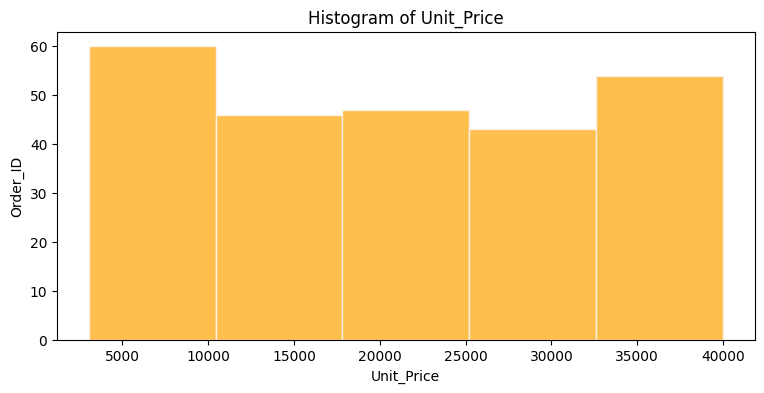

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Unit_Price', color = 'orange',
             edgecolor = 'linen', alpha = 0.7, bins = 5)

plt.title("Histogram of Unit_Price")
plt.xlabel('Unit_Price')
plt.ylabel('Order_ID')
plt.show()

In [ ]:
round(data['Unit_Price'].mean(),2)

np.float64(21098.28)

In [ ]:
data['Unit_Price'].median()

20433.0

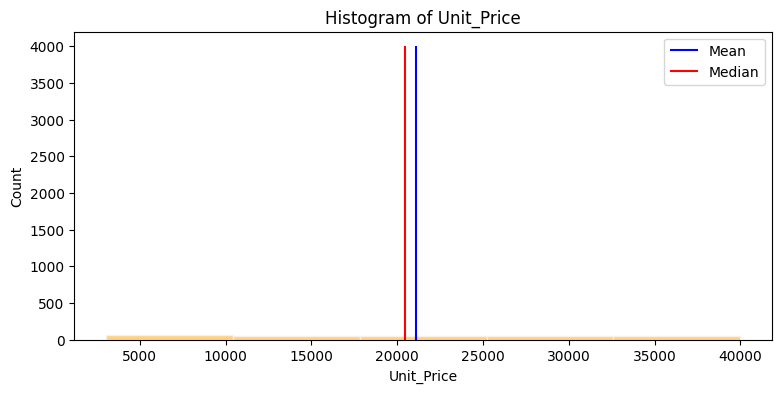

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Unit_Price', color = 'orange',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Unit_Price")
plt.xlabel('Unit_Price')
plt.ylabel('Order_ID')
plt.vlines(data['Unit_Price'].mean(), ymin = 0, ymax = 4000, colors='blue', label='Mean')
plt.vlines(data['Unit_Price'].median(), ymin = 0, ymax = 4000, colors='red', label='Median')
plt.legend()
plt.show()

**Count Plot of Rating**

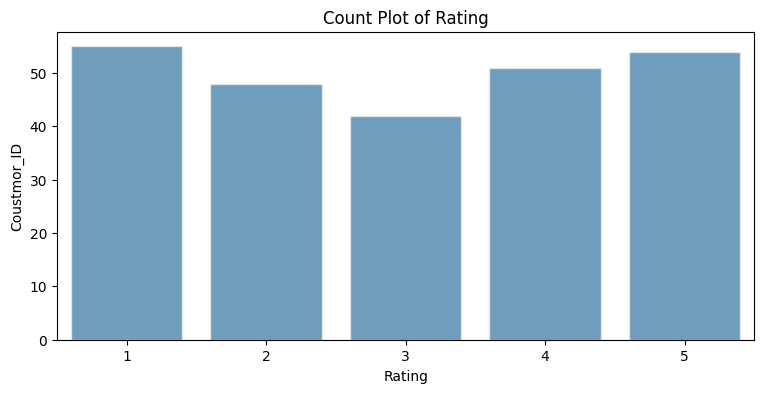

In [ ]:
plt.figure(figsize = (9,4))

sns.countplot(data = data ,x = 'Rating', edgecolor = 'linen', alpha = 0.7)

plt.title("Count Plot of Rating")
plt.xlabel('Rating')
plt.ylabel('Customer_ID')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('/content/ecommerce_furniture_2024 (1).csv')


**Distplot of Rating**

/tmp/ipython-input-2067072024.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Rating'], color = 'blue')


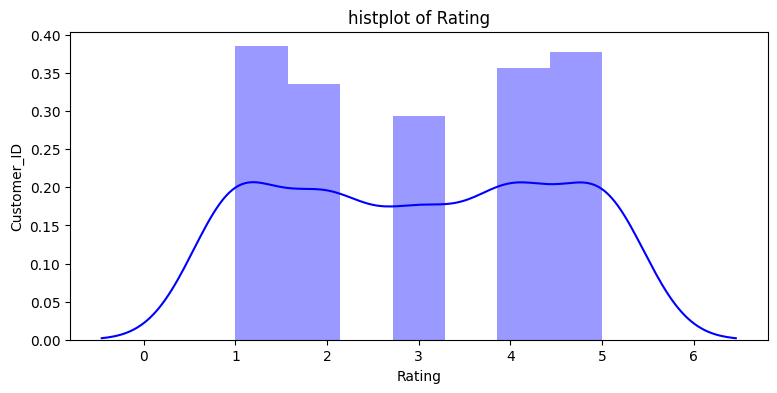

In [ ]:
plt.figure(figsize = (9,4))

sns.distplot(data['Rating'], color = 'blue')

plt.title("histplot of Rating")
plt.xlabel('Rating')
plt.ylabel('Customer_ID')
plt.show()

**Histogram of Rating**

In [ ]:
data['Rating'].skew()

np.float64(-0.01468003482832561)

In [ ]:
data['Rating'].mean()

np.float64(3.004)

In [ ]:
data['Rating'].median()


3.0

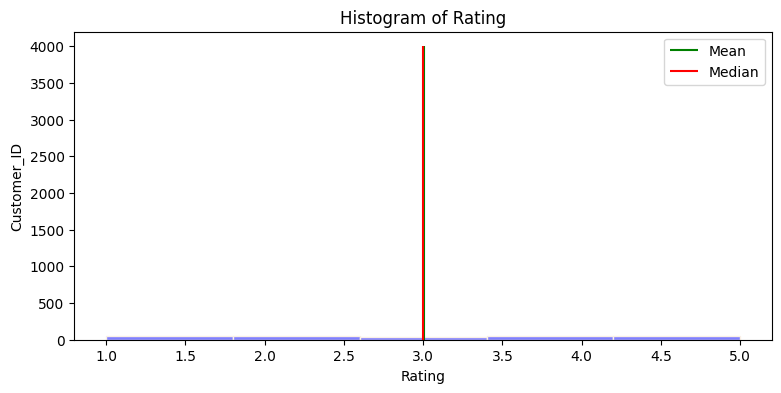

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Rating', color = 'blue',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Rating")
plt.xlabel('Rating')
plt.ylabel('Customer_ID')
plt.vlines(data['Rating'].mean(), ymin = 0, ymax = 4000, colors='green', label='Mean')
plt.vlines(data['Rating'].median(), ymin = 0, ymax = 4000, colors='red', label='Median')
plt.legend()
plt.show()


**Histogram of Total_Sales**

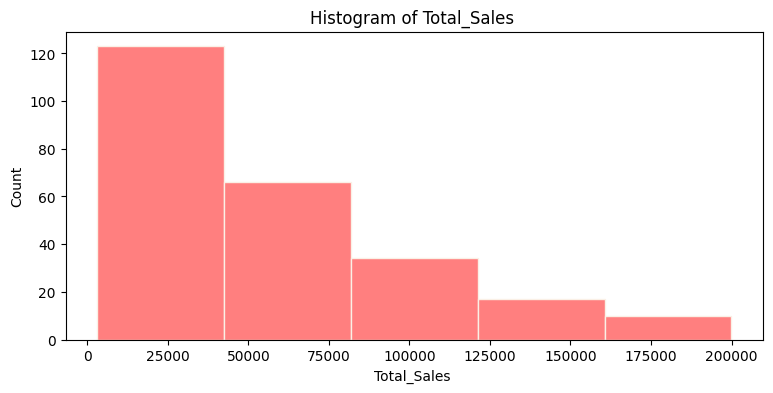

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Total_Sales', color = 'red',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Total_Sales ")
plt.xlabel('Total_Sales ')
plt.ylabel('Count')
plt.show()

In [ ]:
data['Total_Sales'].mean()


In [ ]:
data['Total_Sales'].median()


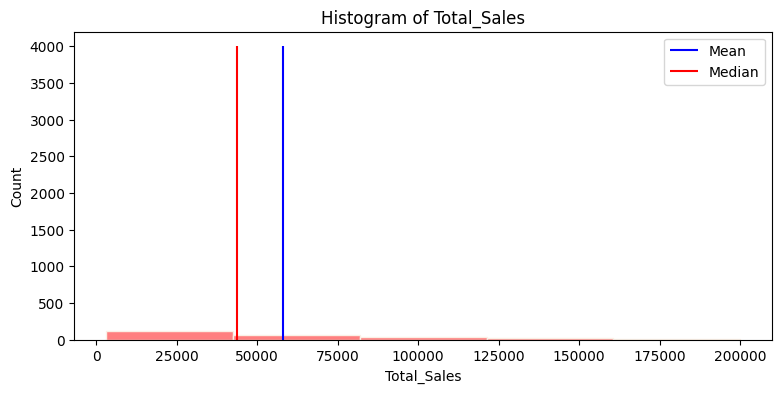

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Total_Sales', color = 'red',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Total_Sales")
plt.xlabel('Total_Sales')
plt.ylabel('Count')
plt.vlines(data['Total_Sales'].mean(), ymin = 0, ymax = 4000, colors='blue', label='Mean')
plt.vlines(data['Total_Sales'].median(), ymin = 0, ymax = 4000, colors='red', label='Median')
plt.legend()
plt.show()


**Total_Sales Over Time**

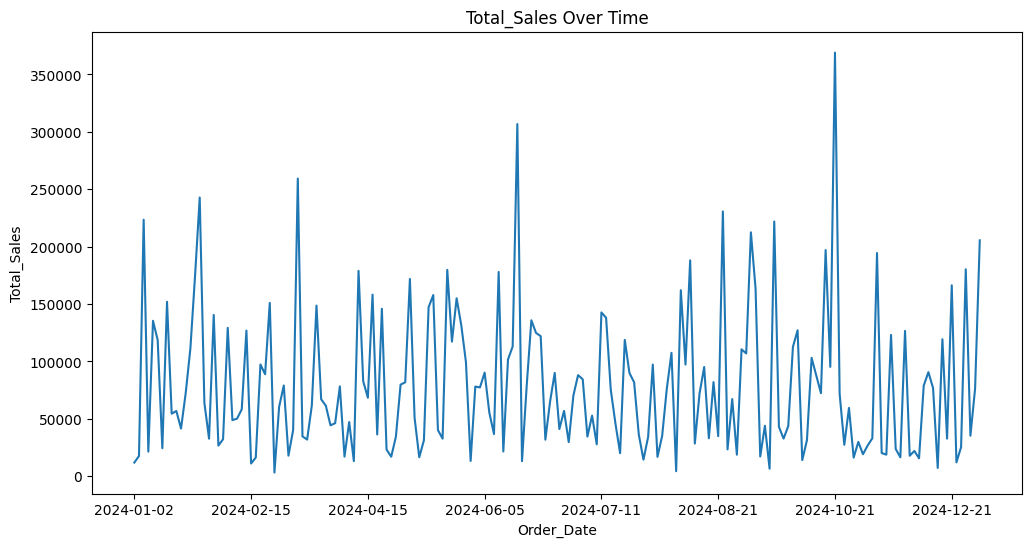

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/ecommerce_furniture_2024 (1).csv')

#Visualize
plt.figure(figsize=(12, 6))
data.groupby('Order_Date')['Total_Sales'].sum().plot()
plt.title('Total_Sales Over Time')
plt.xlabel('Order_Date')
plt.ylabel('Total_Sales')
plt.show()



In [ ]:
import seaborn as sns
sns.set_theme()
df = sns.load_dataset("penguins")

**Distplot of Total_Sales**

/tmp/ipython-input-1934115661.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Total_Sales'], color = 'blue')


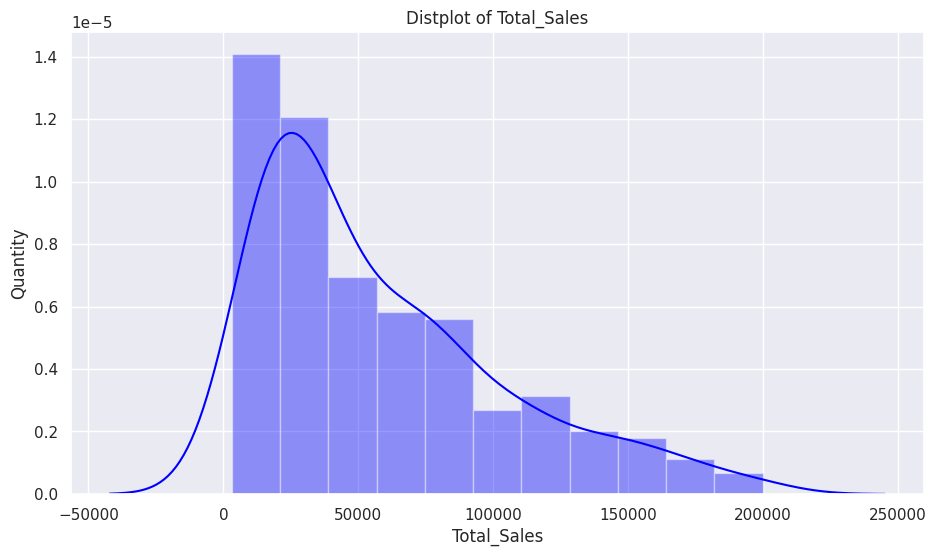

In [ ]:
plt.figure(figsize = (11,6))

sns.distplot(data['Total_Sales'], color = 'blue')

plt.title("Distplot of Total_Sales")
plt.xlabel('Total_Sales')
plt.ylabel('Quantity')
plt.show()


**Count Plot of Quantity**

In [ ]:
Quantity = pd.DataFrame(data['Quantity'].value_counts())

In [ ]:
Quantity.index

Index([5, 1, 3, 2, 4], dtype='int64', name='Quantity')

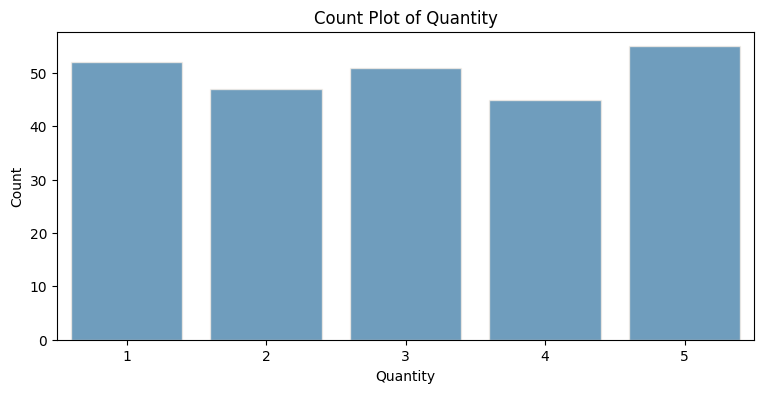

In [ ]:
plt.figure(figsize = (9,4))

sns.countplot(data = data ,x = 'Quantity', edgecolor = 'linen', alpha = 0.7)

plt.title("Count Plot of Quantity")
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

**New Pandas Series that contains the details of the Total Sales and Rating about data.**

In [ ]:
rep_data = pd.DataFrame(index = ['Unit_Price','Rating','Total_Sales','Quantity'],
                     data = [data['Unit_Price'].mean(),data['Rating'].mean(),
                             data['Total_Sales'].mean(),data['Quantity'].value_counts().index[0]])

In [ ]:
rep_data

,0
Unit_Price,21098.2800
Rating,3.0040
Total_Sales,58147.5016
Quantity,5.0000
